# 

In [1]:
import torch
import torch.nn as nn
import torch.distributions as dist
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import numpy as np
import matplotlib.pyplot as plt
import random

In [2]:
# 設置種子
seed = 13   # 42 bin
torch.manual_seed(seed)
random.seed(seed)
np.random.seed(seed)

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(type(device))
print(device)

<class 'torch.device'>
cpu


# Dataset

In [4]:
class GenData():
    '''
    產生dataset
    '''
    def __init__(self, num_samples, vec_size):
        self.num_samples = num_samples
        self.vec_size    = vec_size

    def full_random(self):
        '''
        全部的維度都是獨立的
        '''
        data = torch.randint(0, 2, (self.num_samples, self.vec_size), dtype=torch.float)
        return data
    
    def copy_half(self):
        '''
        向量的前半維度的值 = 向量後半維度的值 -> 這樣設計理論上要能降到一半維度
        總共要幾筆向量
        每個向量的維度
        ideally: 100維可壓到50維
        '''
        first_half = torch.randint(0, 2, (self.num_samples, self.vec_size // 2), dtype=torch.float)
        second_half = first_half.clone()
        return torch.cat((first_half, second_half), dim=1)

    def copy_quartar(self):
        '''
        前四分之一的值 = 後四分之三的值
        ideally: 100維可壓到25維
        '''
        pass
        
    def entangle2_step_1(self):
        '''
        第一個bit跟第二個bit糾纏（這邊設為相反）
        ideally: 100維可壓到50維
        '''
        vector = torch.zeros((self.num_samples, self.vec_size), dtype=torch.float)
        for row in range(self.num_samples):
            # 偶數下標隨機生成 0 或 1
            for i in range(0, self.vec_size, 2):
                vector[row, i] = torch.randint(0, 2, (1,), dtype=torch.float).item()            
            # 奇數下標的元素與前一個元素相反
            for i in range(1, self.vec_size, 2):
                vector[row, i] = 1.0 - vector[row, i - 1]
        return vector

    def entangle2_step_5(self):
        '''
        第一個bit跟第五個bit糾纏（這邊設為相反）
        1~5決定了6~10
        
        ideally: 100維可壓到50維
        '''
        pass

In [5]:
train_size = 10_000
test_size  = 10
vec_size   = 100

dataset_train = GenData(train_size, vec_size).copy_half()
dataset_test  = GenData(test_size, vec_size).copy_half()

In [6]:
print(dataset_train[2])

tensor([1., 1., 1., 1., 1., 0., 0., 1., 1., 0., 0., 1., 1., 1., 0., 1., 0., 1.,
        1., 1., 0., 1., 1., 1., 0., 0., 0., 0., 1., 0., 0., 1., 0., 1., 1., 0.,
        1., 1., 1., 1., 0., 0., 1., 1., 1., 0., 0., 0., 0., 0., 1., 1., 1., 1.,
        1., 0., 0., 1., 1., 0., 0., 1., 1., 1., 0., 1., 0., 1., 1., 1., 0., 1.,
        1., 1., 0., 0., 0., 0., 1., 0., 0., 1., 0., 1., 1., 0., 1., 1., 1., 1.,
        0., 0., 1., 1., 1., 0., 0., 0., 0., 0.])


# Model

In [7]:
class CategoricalVAE(nn.Module):
    
    def __init__(self, N, K):
        
        super().__init__()

        self.N = N
        self.K = K
        self.temperature = 1.0
        
        self.encoder = nn.Sequential(
            nn.Linear(100, 85),
            nn.LeakyReLU(),
            nn.Linear(85, 70),
            nn.LeakyReLU(),
            nn.Linear(70, self.N * self.K)
        )
        
        self.decoder = torch.nn.Sequential(
            nn.Linear(self.N * self.K, 70),
            nn.LeakyReLU(),
            nn.Linear(70, 85),
            nn.LeakyReLU(),
            nn.Linear(85, 100),
            nn.Sigmoid()
        )
        
    def encode(self, inputs):
        '''
        input
        - inputs.shape: [batch_size, flatten_img_size]
        output
        - logits.shape: [batch_size, N*K]
        '''
        logits = self.encoder(inputs)
        return logits

    def decode(self, latent_codes):
        '''
        input
        - latent_codes.shape: [batch_size, N*K]
        output
        - outputs.shape: [batch_size, flatten_img_size]
        '''
        outputs = self.decoder(latent_codes)
        return outputs

    def gumbel_dist(self, shape, eps=1e-20):
        '''
        input
        - shape.shape: [batch_size, N*K]
        output
        - gumbel_noise.shape: [batch_size, N*K]
        '''
        U = torch.rand(shape)
        gumbel_noise = -torch.log(-torch.log(U + eps) + eps)
        return gumbel_noise

    def gumbel_softmax(self, logits, temperature):
        '''
        input
        - logits.shape: [batch_size, N*K]
        - temperature.shape: [1]
        output
        - latent_codes.shape: [batch_size, N*K]
        '''
        # Reshape to [batch_size*N, K]
        batch_size = len(logits)
        logits = logits.view(batch_size * self.N, self.K)
        gumbel_noise = self.gumbel_dist(logits.shape)
        y = logits + gumbel_noise
        latent_codes = nn.functional.softmax(y / temperature, dim=-1)

        # Reshape back to [batch_size, N*K]
        logits = logits.view(batch_size, self.N * self.K)
        latent_codes = latent_codes.view(batch_size, self.N * self.K)

        return latent_codes
    
    def forward(self, inputs, temperature):
        '''
        input
        - inputs.shape: [batch_size, flatten_img_size]
        output
        - logits.shape: [batch_size, N*K]
        - latent_codes.shape: [batch_size, N*K]
        - outputs.shape: [batch_size, flatten_img_size]
        '''
        logits = self.encode(inputs)
        latent_codes = self.gumbel_softmax(logits, temperature)
        outputs = self.decoder(latent_codes)
        return logits, latent_codes, outputs

# Train

In [8]:
batch_size = 100
epochs = 30
learning_rate = 0.001
initial_temperature = 0.1
minimum_temperature = 0.01
temperature_anneal_rate = 0.00003
K = 2     # number of classes
N = 60    # number of categorical distributions

In [9]:
# DataLoader
dataloader_train = DataLoader(dataset=dataset_train,
                              batch_size=batch_size,
                              shuffle=True)

In [10]:
# Loss Function
def cat_kl_div(logits):
    '''
    input
    - logits.shape: [batch_size, N*K]
    output
    - kl.shape: [batch_size, N]
    '''
    # Reshape to [batch_size*N, K]
    batch_size = len(logits)
    logits = logits.view(batch_size*N, K)
    
    q = dist.Categorical(logits=logits)
    p = dist.Categorical(probs=torch.full((batch_size*N, K), 1.0/K)) # uniform bunch of K-class categorical distributions
    kl = dist.kl.kl_divergence(q, p) # kl is of shape [B*N]
    return kl

def loss_func(outputs, labels, logits):
    '''
    input
    - outputs.shape: [batch_size, flatten_img_size]
    - labels.shape: [batch_size, flatten_img_size]
    - logits.shape: [batch_size, N*K]
    output
    - kl_loss.shape: []
    - rec_loss.shape: []
    - loss.shape: []
    '''
    
    rec_loss = nn.functional.binary_cross_entropy(outputs, labels, reduction="mean")
    
    kl_loss = torch.mean(cat_kl_div(logits))

    alpha = 1
    beta = 0.03
    loss =  alpha*rec_loss + beta*kl_loss
    
    return alpha*rec_loss, beta*kl_loss, loss

In [11]:
model = CategoricalVAE(N, K)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
temperature = initial_temperature

In [12]:
# Train
# 檢查梯度的啟用狀態
# for name, param in model.named_parameters():
#     print(f"Layer {name}: requires_grad = {param.requires_grad}")
# print("------------------------------------------")

model.train()

for epoch in range(epochs):
    
    total_kl_loss  = 0
    total_rec_loss = 0
    total_loss     = 0
    
    cnt = 0
    
    for data in dataloader_train:
        '''
        data.shape: [batch_size, num_of_channel=1, img_width=28, img_height=28]
        '''
        
        # Clear Gradients
        model.zero_grad()

        # Reshape the Input Images
        inputs = data
        '''
        inputs.shape: [batch_size, flatten_img_size]
        '''
        
        # Forward
        logits, latent_codes, outputs = model(inputs, temperature)
        '''
        - logits.shape: [batch_size, N*K]
        - latent_codes.shape: [batch_size, N*K]
        - outputs.shape: [batch_size, flatten_img_size]
        '''
        
        # 計算loss
        rec_loss, kl_loss, loss = loss_func(outputs, inputs, logits)    # 一個batch平均的loss
        total_rec_loss += rec_loss.item()
        total_kl_loss  += kl_loss.item()
        total_loss     += loss.item()
        
        # Backward & Update the parameters
        loss.backward()
        optimizer.step()

    # 看梯度
    # for name, param in model.named_parameters():
    #     if param.grad is not None:
    #         print(f"Layer {name}: Gradient norm: {param.grad.norm()}")
    #     else:
    #         print(f"Layer {name}: No gradient computed!")

    cnt += 1
    temperature = np.maximum(initial_temperature*np.exp(-temperature_anneal_rate*cnt), minimum_temperature)

    # 一個epoch平均的loss
    avg_rec_loss = total_rec_loss / len(dataloader_train)
    avg_kl_loss  = total_kl_loss / len(dataloader_train)
    avg_loss     = total_loss / len(dataloader_train)
    print(f"{epoch+1:>3}. avg_loss: {avg_loss:.7f}, avg_rec_loss: {avg_rec_loss:.7f}, avg_kl_loss: {avg_kl_loss:.7f}")

  1. avg_loss: 0.6930031, avg_rec_loss: 0.6928470, avg_kl_loss: 0.0001561
  2. avg_loss: 0.6737294, avg_rec_loss: 0.6703317, avg_kl_loss: 0.0033976
  3. avg_loss: 0.6525186, avg_rec_loss: 0.6465322, avg_kl_loss: 0.0059864
  4. avg_loss: 0.6377101, avg_rec_loss: 0.6296989, avg_kl_loss: 0.0080112
  5. avg_loss: 0.6344120, avg_rec_loss: 0.6254695, avg_kl_loss: 0.0089424
  6. avg_loss: 0.6292240, avg_rec_loss: 0.6199404, avg_kl_loss: 0.0092836
  7. avg_loss: 0.6172320, avg_rec_loss: 0.6071835, avg_kl_loss: 0.0100486
  8. avg_loss: 0.6092690, avg_rec_loss: 0.5983528, avg_kl_loss: 0.0109163
  9. avg_loss: 0.6030022, avg_rec_loss: 0.5915925, avg_kl_loss: 0.0114097
 10. avg_loss: 0.5910419, avg_rec_loss: 0.5790817, avg_kl_loss: 0.0119602
 11. avg_loss: 0.5846513, avg_rec_loss: 0.5720257, avg_kl_loss: 0.0126256
 12. avg_loss: 0.5817424, avg_rec_loss: 0.5686308, avg_kl_loss: 0.0131116
 13. avg_loss: 0.5774094, avg_rec_loss: 0.5639813, avg_kl_loss: 0.0134281
 14. avg_loss: 0.5722155, avg_rec_loss

In [13]:
# Save Model
# torch.save(model.state_dict(), 'catVAE_model_weights.pth')

# Test

In [14]:
# Load Model
# model.load_state_dict(torch.load('catVAE_model_weights.pth', weights_only=True))

In [15]:
batch_size = 2

In [16]:
# DataLoader
dataloader_test = DataLoader(dataset=dataset_test,
                             batch_size=batch_size,
                             shuffle=True)

In [17]:
# Show Image
plt.rcParams['figure.figsize'] = (10.0, 8.0)
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

def show_logits(logits):
    '''
    input
    - logits.shape: [batch_size, N*K]
    '''
    sqrtn = int(np.ceil(np.sqrt(logits.shape[0])))
    for index, logit in enumerate(logits):
        plt.subplot(sqrtn, sqrtn, index+1)
        plt.imshow(logit.reshape(N, K))
        plt.axis('off')
    plt.show()

inputs.shape: torch.Size([2, 100])
Batch 1:
[0, 0, 0, 1, 0, 1, 0, 1, 1, 0]
[1, 1, 1, 1, 0, 0, 1, 0, 0, 1]
[0, 0, 0, 0, 0, 0, 1, 1, 0, 1]
[1, 0, 0, 1, 0, 1, 1, 1, 1, 0]
[1, 1, 1, 1, 1, 1, 0, 1, 1, 1]
[0, 0, 0, 1, 0, 1, 0, 1, 1, 0]
[1, 1, 1, 1, 0, 0, 1, 0, 0, 1]
[0, 0, 0, 0, 0, 0, 1, 1, 0, 1]
[1, 0, 0, 1, 0, 1, 1, 1, 1, 0]
[1, 1, 1, 1, 1, 1, 0, 1, 1, 1]
------------------------------
Batch 2:
[0, 1, 1, 0, 1, 1, 0, 1, 1, 0]
[0, 0, 0, 0, 0, 1, 0, 0, 1, 0]
[0, 1, 1, 0, 0, 1, 0, 0, 1, 0]
[1, 1, 1, 1, 1, 1, 1, 1, 0, 1]
[1, 1, 0, 1, 1, 1, 1, 1, 0, 1]
[0, 1, 1, 0, 1, 1, 0, 1, 1, 0]
[0, 0, 0, 0, 0, 1, 0, 0, 1, 0]
[0, 1, 1, 0, 0, 1, 0, 0, 1, 0]
[1, 1, 1, 1, 1, 1, 1, 1, 0, 1]
[1, 1, 0, 1, 1, 1, 1, 1, 0, 1]
------------------------------
logits.shape: torch.Size([2, 120])


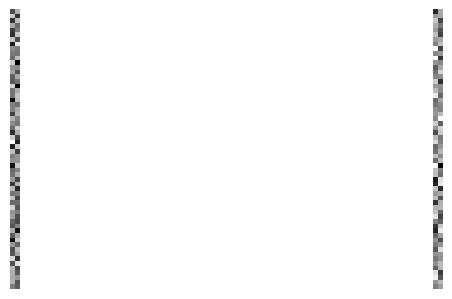

latent_code.shape: torch.Size([2, 120])


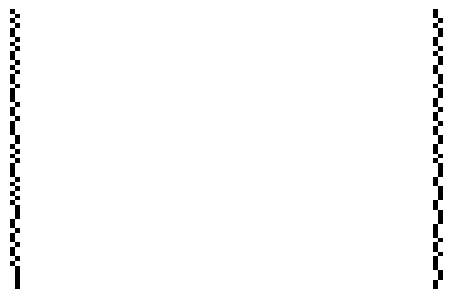

Batch 1:
[0, 0, 1, 1, 0, 1, 0, 1, 0, 0]
[1, 0, 1, 1, 1, 0, 1, 0, 1, 1]
[0, 0, 0, 0, 0, 1, 0, 1, 0, 0]
[1, 0, 1, 1, 0, 1, 1, 1, 1, 0]
[1, 1, 1, 0, 0, 1, 1, 1, 0, 1]
[0, 0, 1, 1, 0, 1, 0, 1, 0, 0]
[1, 0, 1, 1, 1, 0, 1, 0, 1, 1]
[1, 0, 0, 1, 0, 1, 0, 1, 0, 0]
[1, 0, 1, 1, 0, 1, 1, 1, 1, 0]
[1, 0, 1, 0, 0, 1, 0, 1, 0, 1]
------------------------------
Batch 2:
[0, 1, 1, 1, 1, 1, 0, 1, 0, 1]
[1, 1, 0, 1, 0, 1, 1, 0, 0, 1]
[0, 0, 1, 1, 0, 1, 1, 1, 1, 1]
[1, 1, 0, 0, 1, 1, 1, 1, 0, 1]
[0, 1, 0, 1, 1, 1, 1, 0, 0, 1]
[0, 1, 1, 1, 1, 1, 0, 1, 0, 0]
[1, 1, 0, 1, 0, 1, 1, 0, 0, 1]
[0, 0, 1, 1, 0, 1, 1, 1, 1, 1]
[0, 1, 1, 0, 1, 1, 1, 1, 0, 1]
[0, 1, 0, 1, 1, 1, 1, 0, 0, 1]
------------------------------
每個 batch 中相等的元素數量： tensor([72, 65])


In [18]:
model.eval()

with torch.no_grad():
    
    for data in dataloader_test:
    
        inputs = data
        print("inputs.shape:", inputs.shape)
    
        # Inputs
        for i, vector in enumerate(inputs):
            print(f"Batch {i+1}:")
            for j in range(0, len(vector), 10):
                print(vector[j:j+10].int().tolist())
            print("-" * 30)  # 分隔每個 batch
    
        # Inference/Forward
        logits, latent_code, outputs = model(inputs, temperature=0.01)
        '''
        - logits.shape: [batch_size, N*K]
        - latent_codes.shape: [batch_size, N*K]
        - outputs.shape: [batch_size, flatten_img_size]
        '''
        
        # Logits
        print("logits.shape:", logits.shape)
        show_logits(logits)

        # Latent Code
        print("latent_code.shape:", latent_code.shape)
        show_logits(latent_code)
        
        # Outputs
        outputs = (outputs>=0.5).int().float()
        for i, vector in enumerate(outputs):
            print(f"Batch {i+1}:")
            for j in range(0, len(vector), 10):
                print(vector[j:j+10].int().tolist())
            print("-" * 30)  # 分隔每個 batch

        # # 正確率
        # equal_elements = inputs == outputs                          # 比對每個元素是否相等，結果是布林值的 tensor
        # batch_equal_counts = equal_elements.sum(dim=1)              # 對每個 batch 計算相等的元素數量
        # print("每個 batch 中相等的元素數量：", batch_equal_counts)    

        # 根據原始的數據來判斷生成出的元素之間有沒有符合相關性
        
        break

# Generation

In [19]:
batch_size = 1
temperature = 0.01
with torch.no_grad():
    logits = torch.rand((batch_size, N, K))
    latent_code = model.gumbel_softmax(logits, temperature)
    latent_code = (latent_code>=0.5).int().float()
    # print(latent_code.shape)
    outputs = model.decode(latent_code)
    
    outputs = (outputs>=0.5).int().float()
    for i, vector in enumerate(outputs):
            print(f"Batch {i+1}:")
            for j in range(0, len(vector), 10):
                print(vector[j:j+10].int().tolist())
            print("-" * 30)  # 分隔每個 batch

    inputs = outputs
    latent_code_new = model.encode(inputs)

    latent_code_new = (latent_code_new>=0.5).int().float()
    # 正確率
    equal_elements = latent_code == latent_code_new             # 比對每個元素是否相等，結果是布林值的 tensor
    batch_equal_counts = equal_elements.sum(dim=1)              # 對每個 batch 計算相等的元素數量
    print("每個 batch 中相等的元素數量：", batch_equal_counts)
    print("每個 batch 中相等的元素比例：", batch_equal_counts/len(latent_code[0]))

Batch 1:
[1, 1, 1, 0, 0, 0, 1, 1, 0, 0]
[1, 1, 0, 0, 1, 0, 0, 1, 1, 1]
[1, 0, 0, 0, 1, 1, 0, 1, 0, 0]
[1, 0, 1, 1, 1, 1, 1, 1, 0, 0]
[1, 1, 0, 0, 0, 1, 0, 0, 0, 0]
[0, 1, 1, 0, 0, 0, 1, 1, 0, 0]
[1, 1, 0, 0, 1, 0, 1, 1, 1, 1]
[1, 0, 0, 0, 1, 1, 0, 1, 0, 0]
[1, 0, 1, 1, 1, 1, 1, 1, 0, 0]
[1, 1, 1, 1, 0, 1, 0, 0, 0, 0]
------------------------------
每個 batch 中相等的元素數量： tensor([76])
每個 batch 中相等的元素比例： tensor([0.6333])
